In [1]:
import numpy as np

In [2]:
from graphviz import Digraph


def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = f"{{ {n.label} | data {n.data:.4f} | grad {n.grad:.4f} }}", shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [49]:
class Value:
    """ Stores a single scaler value and its gradient """
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self) -> str:
        return f"Value(data={self.data}, grad={self.grad})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = np.tanh(self.data)
        out = Value(t, (self, ), 'tanh')
        return out 
    
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c=  Value(10.0, label='c')
e = a*b; e.label='e'
d = e+c; d.label='d'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
y = L.tanh() ; y.label = 'y'

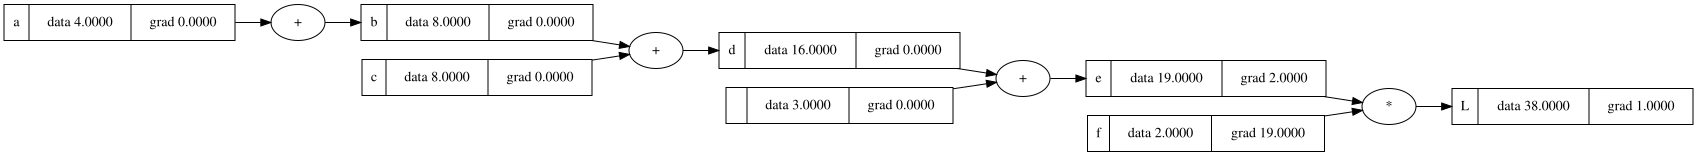

In [50]:
a = Value(4.0, label='a')
b = a+a ; b.label='b'
c = Value(8.0, label='c')
d = b+c; d.label='d'
e = d+3 ; e.label='e'
f = Value(2.0, label='f')
L = e*f; L.label = 'L'
L.grad = 1.0
L._backward()
draw_dot(L)

In [ ]:
# dy/dL = 1
L.grad = 1.0

# dL/dd ?? -> f
# dL/df ?? -> d
d.grad = f.data
f.grad = d.data

# dd/de -> 1 * dL/dd * dL/dL
# dd/dc -> 1 * dL/dd * dL/dL

e.grad = 1 * d.grad * 1
c.grad = 1 * d.grad * 1

# dL/da -> (dL/de) * (de/da) -> -2 * b
# dL/db -> (dL/de) * (de/db) -> -2 * a

a.grad = e.grad * b.data
b.grad = e.grad * a.data

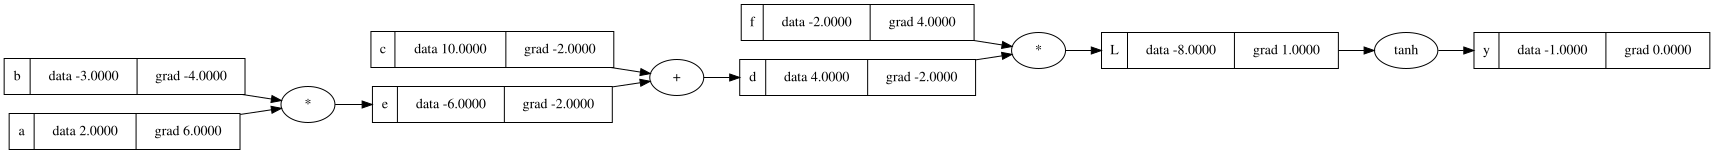

In [13]:
draw_dot(y)